In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -U pyarrow
!pip install transformers
!pip install datasets
!pip install transformers[torch]


zsh:1: no matches found: transformers[torch]


# Dataset Preparation with Hugging Face Datasets

In this notebook, we prepare a text classification dataset using the Hugging Face `datasets` library.
We will:
- Remove unnecessary columns
- Rename columns to standard names
- Inspect label distributions
- Filter the dataset
- Encode labels for training


# Import Required Libraries

In [3]:
from datasets import load_dataset, concatenate_datasets, Dataset
import pandas as pd


# Load the Dataset

In [4]:
dataset = load_dataset("jonathanli/law-stack-exchange")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Id', 'PostTypeId', 'CreationDate', 'Score', 'ViewCount', 'LastActivityDate', 'AnswerCount', 'CommentCount', 'ContentLicense', 'body', 'text_label', 'title'],
        num_rows: 638
    })
    validation: Dataset({
        features: ['Id', 'PostTypeId', 'CreationDate', 'Score', 'ViewCount', 'LastActivityDate', 'AnswerCount', 'CommentCount', 'ContentLicense', 'body', 'text_label', 'title'],
        num_rows: 319
    })
    test: Dataset({
        features: ['Id', 'PostTypeId', 'CreationDate', 'Score', 'ViewCount', 'LastActivityDate', 'AnswerCount', 'CommentCount', 'ContentLicense', 'body', 'text_label', 'title'],
        num_rows: 1596
    })
})

In [6]:
dataset["train"][0]

{'Id': 71340,
 'PostTypeId': 1,
 'CreationDate': '2021-09-01T02:39:58.830',
 'Score': 0,
 'ViewCount': 128.0,
 'LastActivityDate': '2021-09-01T06:43:55.503',
 'AnswerCount': 1.0,
 'CommentCount': 9,
 'ContentLicense': 'CC BY-SA 4.0',
 'body': "I'm trying to comfortably use my laptop at night and now could not find an answer by web-search to the following: Why TVs / laptops etc. do not warn about too bright screen whereas many smartphones warn about too loud sound amplification? I'm asking on law site cause I suspect there were a number of successful lawsuits for impaired hearing from headphones but none for impaired vision from TVs. Am I right here? Digging down - has it happened because there are studies proving impairment for one and none for the other?\n\n\nAdded: I actually doubt my second guess cause there are a lot of enhancements in screen brightness - auto-brightness, night mode.\n\n\n",
 'text_label': 'civil-law',
 'title': 'Why TVs / laptops etc. do not warn about too brirght

In [7]:
dataset["train"].column_names


['Id',
 'PostTypeId',
 'CreationDate',
 'Score',
 'ViewCount',
 'LastActivityDate',
 'AnswerCount',
 'CommentCount',
 'ContentLicense',
 'body',
 'text_label',
 'title']


## Removing Unnecessary Columns

The dataset contains many metadata columns that are not useful for text classification.
We only keep the text content and the label.


In [8]:
dataset = dataset.remove_columns(["Id", "PostTypeId", "CreationDate", 
                                  "Score", "ViewCount", "LastActivityDate",
                                  "AnswerCount", "CommentCount", "ContentLicense", 
                                  "title"])

## Renaming Columns

To follow Hugging Face conventions:
- `text` will be used as the model input
- `label` will be used as the target variable


In [9]:
dataset = dataset.rename_column("text_label", "label")
dataset = dataset.rename_column("body", "text")

## Label Distribution

Before training a model, it is important to analyze how the labels are distributed
in order to detect class imbalance.


<Axes: >

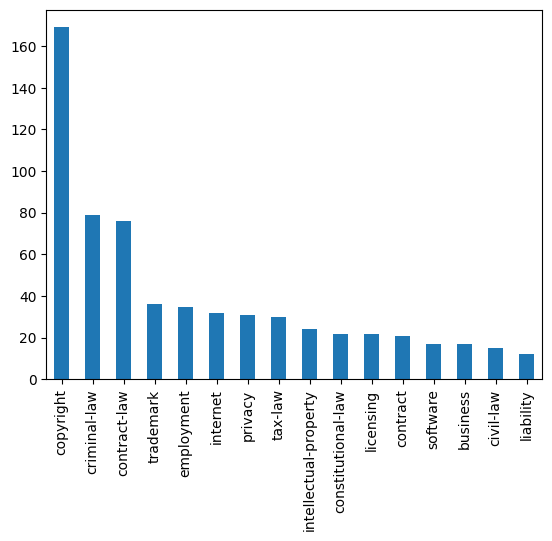

In [10]:

train_labels = pd.Series(dataset["train"]["label"]).value_counts()
train_labels.plot(kind="bar")


In [11]:
from datasets import concatenate_datasets

In [12]:
NUM_TRAINING_SAMPLES = 30
NUM_VAL_SAMPLES = 7
NUM_TESTING_SAMPLES = 5

In [13]:
# criminal-law 
label_6_train_data = dataset['train'].filter(lambda example: example["label"] == 'criminal-law').select(range(NUM_TRAINING_SAMPLES))
label_6_val_data = dataset['validation'].filter(lambda example: example["label"] == 'criminal-law').select(range(NUM_VAL_SAMPLES))
label_6_test_data = dataset['test'].filter(lambda example: example["label"] == 'criminal-law').select(range(NUM_TESTING_SAMPLES))
# employment 
label_7_train_data = dataset['train'].filter(lambda example: example["label"] == 'employment').select(range(NUM_TRAINING_SAMPLES))
label_7_val_data = dataset['validation'].filter(lambda example: example["label"] == 'employment').select(range(NUM_VAL_SAMPLES))
label_7_test_data = dataset['test'].filter(lambda example: example["label"] == 'employment').select(range(NUM_TESTING_SAMPLES))
# tax-law 
label_14_train_data = dataset['train'].filter(lambda example: example["label"] == 'tax-law').select(range(NUM_TRAINING_SAMPLES))
label_14_val_data = dataset['validation'].filter(lambda example: example["label"] == 'tax-law').select(range(NUM_VAL_SAMPLES))
label_14_test_data = dataset['test'].filter(lambda example: example["label"] == 'tax-law').select(range(NUM_TESTING_SAMPLES))
# trademark
label_15_train_data = dataset['train'].filter(lambda example: example["label"] == 'trademark').select(range(NUM_TRAINING_SAMPLES))
label_15_val_data = dataset['validation'].filter(lambda example: example["label"] == 'trademark').select(range(NUM_VAL_SAMPLES))
label_15_test_data = dataset['test'].filter(lambda example: example["label"] == 'trademark').select(range(NUM_TESTING_SAMPLES))

In [14]:
train_data = concatenate_datasets([label_6_train_data, label_7_train_data, label_14_train_data, label_15_train_data])
val_data = concatenate_datasets([label_6_val_data, label_7_val_data, label_14_val_data, label_15_val_data])
test_data = concatenate_datasets([label_6_test_data, label_7_test_data, label_14_test_data, label_15_test_data])


In [15]:
NUM_LABELS = 4


In [16]:
train_data.features

{'text': Value('string'), 'label': Value('string')}

In [17]:
def encode_labels(dataset):
    encoded_data = pd.DataFrame(dataset)
    encoded_data = Dataset.from_pandas(encoded_data)
    encoded_data = encoded_data.class_encode_column("label")
    return encoded_data

In [18]:
train_data = encode_labels(train_data)
val_data = encode_labels(val_data)
test_data = encode_labels(test_data)

Casting to class labels:   0%|          | 0/120 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/28 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/20 [00:00<?, ? examples/s]

In [19]:
train_data.features

{'text': Value('string'),
 'label': ClassLabel(names=['criminal-law', 'employment', 'tax-law', 'trademark'])}

In [20]:
labels = train_data.features['label'].names
ids = range(NUM_LABELS)

id2label = dict(zip(ids, labels))   
label2id = dict(zip(labels, ids)) 

### Import and Load the Tokenizer

In [21]:
from transformers import AutoTokenizer


In [22]:
model_name = 'distilbert-base-cased'

In [23]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

### Define the Tokenization Function
    We define a tokenization function that:
    - Converts text into input IDs
    - Pads sequences to a fixed maximum length
    - Truncates sequences that exceed the model's maximum length
    
    Batch tokenization improves performance and efficiency.


In [24]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True
    )


### Apply Tokenization to the Datasets
We apply the tokenization function to the training, validation, and test datasets.
The `batched=True` argument enables batch processing.


In [25]:
tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_val = val_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)


Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

### Inspect the Tokenized Dataset
We inspect the features of the tokenized training dataset.
We should now see numerical inputs required by the model.


In [26]:
tokenized_train.features


{'text': Value('string'),
 'label': ClassLabel(names=['criminal-law', 'employment', 'tax-law', 'trademark']),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

### Remove the Raw Text Column
After tokenization, the raw text column is no longer needed.
The model only uses numerical inputs such as input IDs and attention masks.


In [27]:
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])


### Final Dataset Ready for Training
At this point, the dataset is fully prepared for model training:
- Labels are encoded
- Text is tokenized
- Input IDs and attention masks are ready

The dataset can now be used directly with a Hugging Face Trainer or a custom PyTorch training loop.


In [28]:
tokenized_train


Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 120
})

# Training a Model

At this stage, we have selected a pretrained model and prepared our dataset.
We are now ready to fine-tune the model using Hugging Face’s Trainer API.


## Load the Pretrained Model
We load a pretrained model for sequence classification.
The model is initialized with the correct number of labels and label mappings.


In [29]:
from transformers import AutoModelForSequenceClassification


In [30]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training Arguments
TrainingArguments define how the model will be trained.
They control aspects such as:
- Output directory
- Evaluation strategy
- Logging and saving behavior


In [31]:
from transformers import TrainingArguments


In [32]:
pip install 'accelerate>=1.1.0'

Note: you may need to restart the kernel to use updated packages.


In [33]:
!pip install -U accelerate


In [34]:
raining_args = TrainingArguments(output_dir="my_test_model", eval_strategy="epoch")

## Evaluation Setup
We define how the model will be evaluated.
In this example, we use accuracy as the evaluation metric.


In [35]:
!pip install evaluate 
import evaluate

In [36]:
metric = evaluate.load("accuracy")


## Define the Evaluation Function
The compute_metrics function converts model outputs into predictions
and computes the evaluation metric.


In [37]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)


## Initialize the Trainer 
The Trainer class connects:
- the model
- training arguments
- datasets
- evaluation function

This greatly simplifies the fine-tuning process.


In [38]:
from transformers import Trainer


In [39]:
"""trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)"""


'trainer = Trainer(\n    model=model,\n    args=training_args,\n    train_dataset=tokenized_train,\n    eval_dataset=tokenized_val,\n    compute_metrics=compute_metrics\n)'

In [40]:
from transformers import TrainingArguments, Trainer # Assure-toi d'avoir bien importé TrainingArguments

# CORRECTION ICI : On utilise TrainingArguments, pas Trainer
training_args = TrainingArguments( 
    output_dir="fast_model",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True,                 # Mixed Precision activé !
    dataloader_num_workers=2,
    eval_strategy="epoch",
    save_strategy="epoch",
)

# Ensuite, tu peux créer ton Trainer (cellule suivante)
trainer = Trainer(
    model=model,
    args=training_args,        # On passe les arguments corrigés ici
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
    # data_collator=data_collator # Ajoute ceci si tu utilises le dynamic padding
)

# N'oublie pas d'utiliser DataCollatorWithPadding + truncation=True (sans padding max) !

## Start Training
We can now start fine-tuning the model.
The Trainer handles the entire training loop automatically.


In [41]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.323207,0.750000
2,No log,1.079032,0.892857
3,No log,0.690639,0.892857
4,No log,0.465655,0.892857
5,No log,0.322200,0.964286
6,No log,0.271587,0.964286
7,No log,0.209105,0.964286
8,No log,0.206290,0.964286
9,No log,0.204848,0.964286
10,No log,0.200448,0.964286


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=150, training_loss=0.45321507771809894, metrics={'train_runtime': 38.8578, 'train_samples_per_second': 30.882, 'train_steps_per_second': 3.86, 'total_flos': 158966548070400.0, 'train_loss': 0.45321507771809894, 'epoch': 10.0})

## Training Complete
Once training is complete, we obtain a fine-tuned model.
The model has learned patterns from our labeled text data
and can now be evaluated or used for inference.

In [42]:
trainer.evaluate(tokenized_test)

{'eval_loss': 0.2562461793422699,
 'eval_accuracy': 0.95,
 'eval_runtime': 0.2162,
 'eval_samples_per_second': 92.505,
 'eval_steps_per_second': 13.876,
 'epoch': 10.0}

### Import Optuna

Optuna is an automated hyperparameter optimization framework.
It will be used to explore different combinations of hyperparameters efficiently.


In [43]:
!pip install -q optuna 


In [44]:
import optuna


### Model Initialization Function

Since each tuning run requires training a new model with different hyperparameters,
we define a function that initializes a fresh model for every tuning trial.


In [45]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, 
                                                              num_labels=NUM_LABELS, 
                                                              label2id=label2id, 
                                                              id2label=id2label)


### Define the Hyperparameter Search Space

We define a function that controls the space in which Optuna searches
for the best hyperparameters.

We tune:
- Learning rate
- Batch size
- Number of training epochs

Optuna uses `suggest_*()` methods to sample values.


In [46]:
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
        "num_train_epochs": trial.suggest_categorical("num_train_epochs", [2, 3, 5])
    }

## Training Arguments for Hyperparameter Tuning

We define training arguments for the tuning runs.
These values act as placeholders and will be overridden
during each hyperparameter trial.


In [47]:
tuning_training_args = TrainingArguments(
    output_dir="model_tuning_output",
    eval_strategy="epoch",
    learning_rate=0.1,  
    per_device_train_batch_size=16,  
    num_train_epochs=3, 
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Create the Tuning Trainer

We now create the Trainer for hyperparameter tuning.
It receives:

- The model initialization function
- Training arguments
- Training and validation datasets
- The tokenizer as the processing class
- The compute_metrics function


In [48]:
tuning_trainer = Trainer(
    model_init=model_init,
    args=tuning_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Run Hyperparameter Search

We launch the hyperparameter search using Optuna.
Multiple trials are executed to find the best combination of hyperparameters.

⚠️ This process may take some time, especially with a large search space.


In [49]:
best_trial = tuning_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=5
)

[I 2026-02-03 02:08:30,440] A new study created in memory with name: no-name-06bc820b-39da-4ab9-aa49-77b83d94ee6d


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.884393,0.892857
2,No log,0.530801,0.892857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.708347,0.892857
2,No log,0.397455,0.928571


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-02-03 02:09:25,923] Trial 4 finished with value: 0.9285714285714286 and parameters: {'learning_rate': 0.00010070641970917561, 'per_device_train_batch_size': 8, 'num_train_epochs': 2}. Best is trial 3 with value: 0.9642857142857143.


### Display Best Hyperparameters

After the search is complete, we print the best hyperparameter
values found by Optuna.


In [50]:
print("Best Hyperparameters:", best_trial.hyperparameters)


Best Hyperparameters: {'learning_rate': 9.001905212697694e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 5}


### Save the Tuned Model and Tokenizer

We save the newly tuned model and tokenizer
so they can be reused for inference or deployment.


In [64]:


tuning_trainer.save_model("my_tuned_model")

# Save tokenizer (always explicit)
tokenizer.save_pretrained("my_tuned_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_tuned_model/tokenizer_config.json', 'my_tuned_model/tokenizer.json')

### Next Step

Now that we have a finely tuned model, the next step is to evaluate it
on unseen data and perform inference to measure its real-world performance.


# Inference

In this section, we test our fine-tuned model by running inference
and evaluating its predictions on new or unseen text data.


## Load the Fine-Tuned Model and Tokenizer

We load the model and tokenizer saved during the hyperparameter tuning step.
These will be used to perform inference.


In [58]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

my_model = AutoModelForSequenceClassification.from_pretrained("my_tuned_model")
my_tokenizer = AutoTokenizer.from_pretrained("tokenizer")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Create a Text Classification Pipeline

We create a Hugging Face pipeline to simplify the inference process.
The pipeline handles tokenization, model inference, and post-processing.


In [59]:
from transformers import pipeline

my_text_classifier = pipeline(
    "text-classification",
    model=my_model,
    tokenizer=my_tokenizer
)


## Select a Sample from the Dataset

We randomly select a text sample from the test dataset
to evaluate the model's prediction.


In [60]:
import random

rand_sample = random.randint(0, len(test_data) - 1)

sample_text = test_data[rand_sample]["text"]
sample_label = test_data[rand_sample]["label"]


## Run Inference on the Sample Text

We pass the selected text through the classification pipeline
to obtain the model's prediction.


In [61]:
my_model_result = my_text_classifier(sample_text)


## Compare Prediction with Ground Truth

We compare the predicted label with the true label
to assess whether the model made a correct prediction.


In [62]:
print("Text to classify:\n")
print(sample_text)
print("\nTrue label:", sample_label)
print("Predicted label:", my_model_result[0]["label"])
print("Prediction score:", my_model_result[0]["score"])


Text to classify:

I would have thought this would've been asked already, but I searched this site and the Internet, and I couldn't find anything. Apologies if this is a duplicate.


As computers become increasingly autonomous, there have already been a handful of incidents where computers have done things that would be criminal for a person to do. For example, a self-driving car killed a pedestrian, and a Twitter bot made a death threat. Moreover, both of these computers were essentially operating under their own decision-making processes and were not directly controlled by any human.


Could it be possible for prosecutors to file criminal charges against a computer? Is there some standard of sentience that the computer would have to achieve in order to indict it?
(United States)




True label: 0
Predicted label: criminal-law
Prediction score: 0.9772288799285889


## Interpretation of the Result

The model outputs:
- A predicted class label
- A confidence score

A high confidence score indicates that the model is confident
in its prediction.


## Conclusion

The fine-tuned model is able to correctly classify the text
with a strong level of confidence, demonstrating the effectiveness
of hyperparameter tuning and fine-tuning.
